## Import and config

In [1]:
import os
import glob
import copy
import time
import random

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import decimate
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


## Data paths and file table

In [3]:
DATASET_PATH = "/Users/stijnroos/VisualStudio/DL_data/"

RAW_FOLDERS = {
    "intra_train": os.path.join(DATASET_PATH, "Intra", "train"),
    "intra_test": os.path.join(DATASET_PATH, "Intra", "test"),
    "cross_train": os.path.join(DATASET_PATH, "Cross", "train"),
    "cross_test1": os.path.join(DATASET_PATH, "Cross", "test1"),
    "cross_test2": os.path.join(DATASET_PATH, "Cross", "test2"),
    "cross_test3": os.path.join(DATASET_PATH, "Cross", "test3"),
}

def parse_filename(path):
    name = os.path.basename(path).replace(".h5", "")
    parts = name.split("_")
    subject = parts[-2]
    chunk = int(parts[-1])
    task = "_".join(parts[:-2])
    return task, subject, chunk


rows = []

for split_name, folder in RAW_FOLDERS.items():
    files = sorted(glob.glob(os.path.join(folder, "*.h5")))

    for file in files:
        task, subject, chunk = parse_filename(file)

        rows.append({
            "split": split_name,
            "file": os.path.basename(file),
            "task": task,
            "subject": subject,
            "chunk": chunk,
            "path": file,
        })

df_files = pd.DataFrame(rows)

print(df_files.shape)
df_files.head()

(152, 6)


,split,file,task,subject,chunk,path
0,intra_train,rest_105923_1.h5,rest,105923,1,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
1,intra_train,rest_105923_2.h5,rest,105923,2,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
2,intra_train,rest_105923_3.h5,rest,105923,3,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
3,intra_train,rest_105923_4.h5,rest,105923,4,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
4,intra_train,rest_105923_5.h5,rest,105923,5,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...


## File readings and labels

In [4]:
def get_dataset_name(file_name_with_dir):
    filename_without_dir = file_name_with_dir.split("/")[-1]
    temp = filename_without_dir.split("_")[:-1]
    dataset_name = "_".join(temp)
    return dataset_name


def read_h5_file(filepath):
    dataset_name = get_dataset_name(filepath)

    with h5py.File(filepath, "r") as f:
        X = f[dataset_name][:]

    return X, dataset_name

TASK_TO_LABEL = {
    "rest": 0,
    "task_story_math": 1,
    "task_working_memory": 2,
    "task_motor": 3,
}

LABEL_TO_TASK = {v: k for k, v in TASK_TO_LABEL.items()}
CLASS_NAMES = [LABEL_TO_TASK[i] for i in range(len(LABEL_TO_TASK))]

print(TASK_TO_LABEL)

{'rest': 0, 'task_story_math': 1, 'task_working_memory': 2, 'task_motor': 3}


## Data preprocessing

In [5]:
def preprocess_meg(
    X,
    downsample_factor=4,
    scale=1e15,
    eps=1e-12,
):
    X = X * scale

    if downsample_factor is not None and downsample_factor > 1:
        X = decimate(X, q=downsample_factor, axis=1, zero_phase=True)

    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    X = (X - mean) / (std + eps)

    return X.astype(np.float32)


def make_windows(X, window_size=512, stride=256):
    windows = []

    for start in range(0, X.shape[1] - window_size + 1, stride):
        end = start + window_size
        windows.append(X[:, start:end])

    if len(windows) == 0:
        return np.empty((0, X.shape[0], window_size), dtype=np.float32)

    return np.stack(windows)

#### Load one split with preprocessing

In [6]:
def load_windowed_split(
    df_split,
    window_size=512,
    stride=256,
    downsample_factor=4,
):
    X_all = []
    y_all = []
    file_all = []

    for _, row in df_split.iterrows():
        X_raw, _ = read_h5_file(row["path"])

        X_processed = preprocess_meg(
            X_raw,
            downsample_factor=downsample_factor,
        )

        windows = make_windows(
            X_processed,
            window_size=window_size,
            stride=stride,
        )

        if len(windows) == 0:
            continue

        label = TASK_TO_LABEL[row["task"]]

        X_all.append(windows)
        y_all.extend([label] * len(windows))
        file_all.extend([row["file"]] * len(windows))

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.array(y_all, dtype=np.int64)
    file_all = np.array(file_all)

    return X_all, y_all, file_all

#### Dataset and Dataloader

In [7]:
class MEGWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def make_loader(X, y, batch_size=32, shuffle=False):
    dataset = MEGWindowDataset(X, y)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
    )

#### Train/Validation splits

In [8]:
def grouped_train_val_split(
    X,
    y,
    groups,
    val_size=0.2,
    random_state=42,
):
    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=val_size,
        random_state=random_state,
    )

    train_idx, val_idx = next(
        gss.split(X, y, groups=groups)
    )

    return (
        X[train_idx],
        y[train_idx],
        X[val_idx],
        y[val_idx],
        groups[train_idx],
        groups[val_idx],
    )

## Model Definitions

In [ ]:
from experiments import MEG1DCNN2, MEG1DCNN3, CNN1DResNet

## Training and evaluation

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=40,
    print_every=10,
):
    best_val_acc = -np.inf
    best_state = None

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
            device,
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        if print_every is not None and epoch % print_every == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"train acc {train_acc:.3f} | "
                f"val acc {val_acc:.3f}"
            )

    model.load_state_dict(best_state)

    return model, history, best_val_acc


## Prediction helper

In [11]:
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            preds = logits.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    return np.array(all_labels), np.array(all_preds)

## Define experiment grid

In [ ]:
from experiments import MODEL_REGISTRY, EXPERIMENTS_WINDOWS

## Run Intra experiment 

In [13]:
def run_intra_experiment(config, verbose=True):
    set_seed(SEED)

    print(f"\nRunning intra experiment: {config['name']}")

    df_intra_train = df_files[df_files["split"] == "intra_train"].reset_index(drop=True)
    df_intra_test = df_files[df_files["split"] == "intra_test"].reset_index(drop=True)

    X_intra_train, y_intra_train, files_intra_train = load_windowed_split(
        df_intra_train,
        window_size=config["window_size"],
        stride=config["stride"],
        downsample_factor=config["downsample_factor"],
    )

    X_intra_test, y_intra_test, files_intra_test = load_windowed_split(
        df_intra_test,
        window_size=config["window_size"],
        stride=config["stride"],
        downsample_factor=config["downsample_factor"],
    )

    X_train, y_train, X_val, y_val, _, _ = grouped_train_val_split(
        X_intra_train,
        y_intra_train,
        files_intra_train,
        val_size=0.2,
        random_state=SEED,
    )

    train_loader = make_loader(
        X_train,
        y_train,
        batch_size=config["batch_size"],
        shuffle=True,
    )

    val_loader = make_loader(
        X_val,
        y_val,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    test_loader = make_loader(
        X_intra_test,
        y_intra_test,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    model_class = MODEL_REGISTRY[config["model_name"]]

    model = model_class(
        n_channels=X_train.shape[1],
        n_classes=len(TASK_TO_LABEL),
        dropout=config["dropout"],
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    start_time = time.time()

    model, history, best_val_acc = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        epochs=config["epochs"],
        print_every=10,
    )

    train_time = time.time() - start_time

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device,
    )

    result = {
        **config,
        "setting": "intra",
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "train_time": train_time,
        "history": history,
        "model": model,
        "test_loader": test_loader,
    }

    print(
        f"Finished {config['name']} | "
        f"val acc: {best_val_acc:.3f} | "
        f"test acc: {test_acc:.3f}"
    )

    return result

In [14]:
# intra_results = []

# for config in EXPERIMENTS_WINDOWS:
#     result = run_intra_experiment(config)
#     intra_results.append(result)

# intra_summary = pd.DataFrame([
#     {
#         k: v
#         for k, v in result.items()
#         if k not in ["history", "model", "test_loader"]
#     }
#     for result in intra_results
# ])

# intra_summary.sort_values("test_acc", ascending=False)

In [ ]:
# Run best model for intra test set and show confusion matrix
best_result_intra = {
        "name": "cnn3_win512_lr3e4_do05_wd1e3",
        "model_name": "MEG1DCNN3",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
}

result_intra = run_intra_experiment(best_result_intra)


Running intra experiment: cnn3_win512_lr3e4_do05_wd1e3
Epoch 010 | train acc 0.519 | val acc 0.139
Epoch 020 | train acc 0.567 | val acc 0.199
Epoch 030 | train acc 0.593 | val acc 0.203
Epoch 040 | train acc 0.640 | val acc 0.294
Epoch 050 | train acc 0.663 | val acc 0.325
Epoch 060 | train acc 0.697 | val acc 0.372
Epoch 070 | train acc 0.674 | val acc 0.385
Epoch 080 | train acc 0.686 | val acc 0.398
Finished cnn3_win512_lr3e4_do05_wd1e3 | val acc: 0.411 | test acc: 0.708


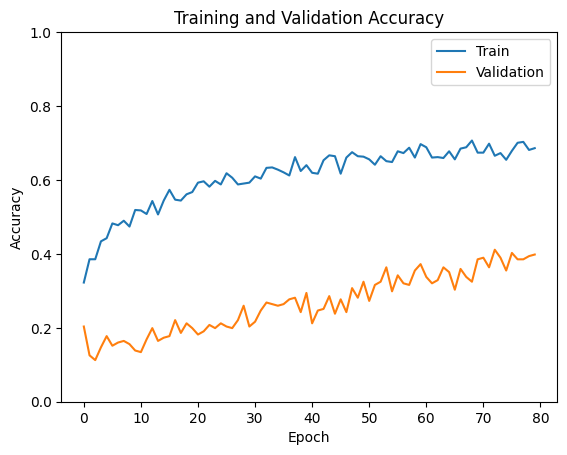

In [27]:

# plot the train history and validation history of this run
plt.plot(result_intra["history"]["train_acc"], label="Train")
plt.plot(result_intra["history"]["val_acc"], label="Validation")
plt.xlabel("Epoch")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


## Run Cross experiment

In [17]:
def run_cross_experiment(config):
    set_seed(SEED)

    print(f"\nRunning cross experiment: {config['name']}")

    df_cross_train = df_files[df_files["split"] == "cross_train"].reset_index(drop=True)
    df_cross_test1 = df_files[df_files["split"] == "cross_test1"].reset_index(drop=True)
    df_cross_test2 = df_files[df_files["split"] == "cross_test2"].reset_index(drop=True)
    df_cross_test3 = df_files[df_files["split"] == "cross_test3"].reset_index(drop=True)

    X_cross_train, y_cross_train, files_cross_train = load_windowed_split(
        df_cross_train,
        window_size=config["window_size"],
        stride=config["stride"],
        downsample_factor=config["downsample_factor"],
    )

    X_cross_test1, y_cross_test1, _ = load_windowed_split(
        df_cross_test1,
        window_size=config["window_size"],
        stride=config["stride"],
        downsample_factor=config["downsample_factor"],
    )

    X_cross_test2, y_cross_test2, _ = load_windowed_split(
        df_cross_test2,
        window_size=config["window_size"],
        stride=config["stride"],
        downsample_factor=config["downsample_factor"],
    )

    X_cross_test3, y_cross_test3, _ = load_windowed_split(
        df_cross_test3,
        window_size=config["window_size"],
        stride=config["stride"],
        downsample_factor=config["downsample_factor"],
    )

    X_train, y_train, X_val, y_val, _, _ = grouped_train_val_split(
        X_cross_train,
        y_cross_train,
        files_cross_train,
        val_size=0.2,
        random_state=SEED,
    )

    train_loader = make_loader(
        X_train,
        y_train,
        batch_size=config["batch_size"],
        shuffle=True,
    )

    val_loader = make_loader(
        X_val,
        y_val,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    test1_loader = make_loader(
        X_cross_test1,
        y_cross_test1,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    test2_loader = make_loader(
        X_cross_test2,
        y_cross_test2,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    test3_loader = make_loader(
        X_cross_test3,
        y_cross_test3,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    model_class = MODEL_REGISTRY[config["model_name"]]

    model = model_class(
        n_channels=X_train.shape[1],
        n_classes=len(TASK_TO_LABEL),
        dropout=config["dropout"],
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    start_time = time.time()

    model, history, best_val_acc = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        epochs=config["epochs"],
        print_every=10,
    )

    train_time = time.time() - start_time

    test1_loss, test1_acc = evaluate(model, test1_loader, criterion, device)
    test2_loss, test2_acc = evaluate(model, test2_loader, criterion, device)
    test3_loss, test3_acc = evaluate(model, test3_loader, criterion, device)

    mean_test_acc = np.mean([test1_acc, test2_acc, test3_acc])

    result = {
        **config,
        "setting": "cross",
        "best_val_acc": best_val_acc,
        "test1_acc": test1_acc,
        "test2_acc": test2_acc,
        "test3_acc": test3_acc,
        "mean_test_acc": mean_test_acc,
        "train_time": train_time,
        "history": history,
        "model": model,
        "test_loaders": [test1_loader, test2_loader, test3_loader],
    }

    print(
        f"Finished {config['name']} | "
        f"val acc: {best_val_acc:.3f} | "
        f"mean test acc: {mean_test_acc:.3f}"
    )

    return result

In [18]:
# cross_results = []

# for config in EXPERIMENTS_WINDOWS:
#     result = run_cross_experiment(config)
#     cross_results.append(result)

# cross_summary = pd.DataFrame([
#     {
#         k: v
#         for k, v in result.items()
#         if k not in ["history", "model", "test_loaders"]
#     }
#     for result in cross_results
# ])

# cross_summary.sort_values("mean_test_acc", ascending=False)

In [19]:
best_result_cross = {
        "name": "cnn2_win1024_lr3e4_do05_wd1e3",
        "model_name": "MEG1DCNN2",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 1024,
        "stride": 512,
        "downsample_factor": 4,
}

result_cross = run_cross_experiment(best_result_cross)


Running cross experiment: cnn2_win1024_lr3e4_do05_wd1e3
Epoch 010 | train acc 0.844 | val acc 0.649
Epoch 020 | train acc 0.983 | val acc 0.760
Epoch 030 | train acc 0.968 | val acc 0.764
Epoch 040 | train acc 0.991 | val acc 0.764
Epoch 050 | train acc 0.994 | val acc 0.779
Epoch 060 | train acc 0.990 | val acc 0.793
Epoch 070 | train acc 0.998 | val acc 0.798
Epoch 080 | train acc 0.989 | val acc 0.774
Finished cnn2_win1024_lr3e4_do05_wd1e3 | val acc: 0.851 | mean test acc: 0.525


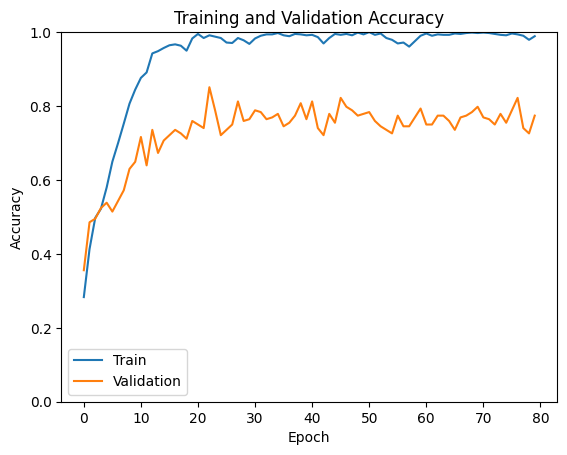

In [26]:
# plot train history and validation history of this run
plt.plot(result_cross["history"]["train_acc"], label="Train")
plt.plot(result_cross["history"]["val_acc"], label="Validation")
plt.xlabel("Epoch")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

## Plotting experiments

In [20]:
def plot_histories(results, metric="val_acc"):
    plt.figure(figsize=(10, 5))

    for result in results:
        plt.plot(
            result["history"][metric],
            label=result["name"],
        )

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(metric)
    plt.legend()
    plt.show()

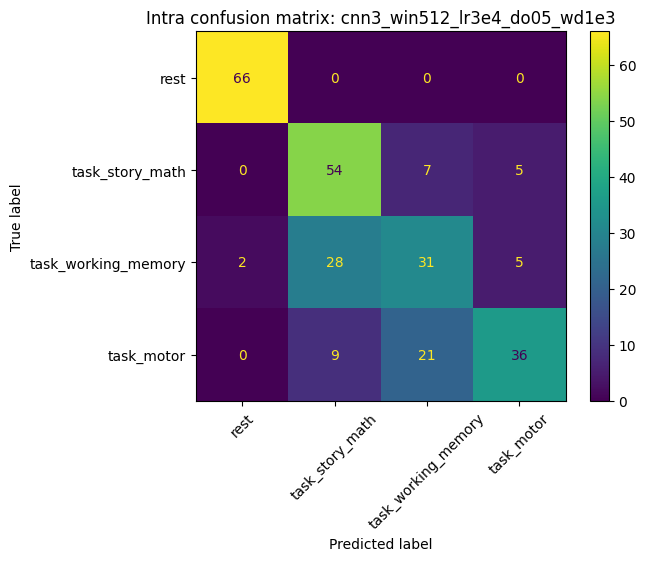

                     precision    recall  f1-score   support

               rest       0.97      1.00      0.99        66
    task_story_math       0.59      0.82      0.69        66
task_working_memory       0.53      0.47      0.50        66
         task_motor       0.78      0.55      0.64        66

           accuracy                           0.71       264
          macro avg       0.72      0.71      0.70       264
       weighted avg       0.72      0.71      0.70       264



In [24]:

y_true, y_pred = get_predictions(
    result_intra["model"],
    result_intra["test_loader"],
    device,
)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
)

disp.plot(values_format="d")
plt.title(f"Intra confusion matrix: {result_intra['name']}")
plt.xticks(rotation=45)
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
))

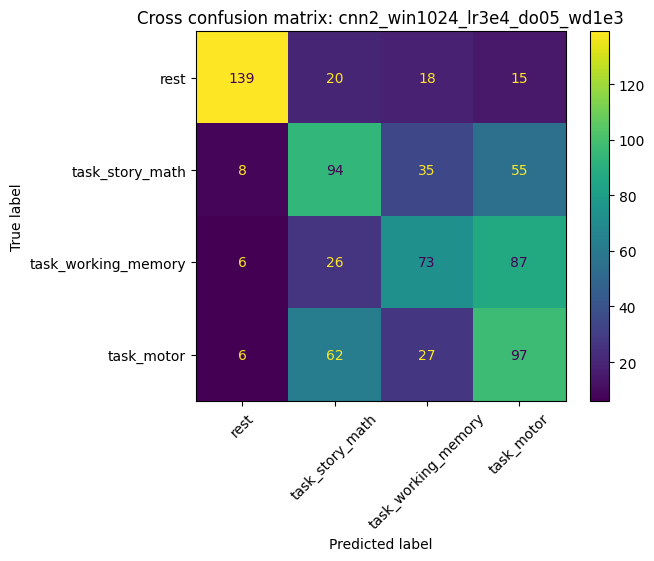

                     precision    recall  f1-score   support

               rest       0.87      0.72      0.79       192
    task_story_math       0.47      0.49      0.48       192
task_working_memory       0.48      0.38      0.42       192
         task_motor       0.38      0.51      0.43       192

           accuracy                           0.52       768
          macro avg       0.55      0.52      0.53       768
       weighted avg       0.55      0.52      0.53       768



In [25]:
all_y_true = []
all_y_pred = []

for loader in result_cross["test_loaders"]:
    y_true, y_pred = get_predictions(
        result_cross["model"],
        loader,
        device,
    )

    all_y_true.append(y_true)
    all_y_pred.append(y_pred)

all_y_true = np.concatenate(all_y_true)
all_y_pred = np.concatenate(all_y_pred)

cm = confusion_matrix(all_y_true, all_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
)

disp.plot(values_format="d")
plt.title(f"Cross confusion matrix: {result_cross['name']}")
plt.xticks(rotation=45)
plt.show()

print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=CLASS_NAMES,
))